## Loading Data:

In [1]:
import pandas as pd

In [2]:
df =pd.read_csv("titanic.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Data Cleaning:

In [6]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [8]:
df=df.drop(columns=['Cabin'])

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.0 KB


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [13]:
df=df.drop(columns=['PassengerId' , 'Name' , 'Ticket'])

In [14]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.8 KB


## One hot Encoding:

In [16]:
df=pd.get_dummies(df, columns=['Sex' , 'Embarked'], drop_first=True)

In [17]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [18]:
x=df.drop(columns=['Survived'])

In [19]:
y=df['Survived']

## 80/20 Split of Data:

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [21]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(712, 8)
(712,)
(179, 8)
(179,)


## Building the Pipeline:

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [23]:
pipeline = Pipeline ([ ('scaler' , StandardScaler()) , ('model' , RandomForestClassifier(random_state=42)) ])

In [24]:
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pclass','Age','SibSp',...,'Sex_male','Embarked_Q','Embarked_S']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
y_pred_pl = pipeline.predict(x_test)

## Stats of Predictions:

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [27]:
accuracy = accuracy_score(y_test,y_pred_pl)
precision = precision_score(y_test,y_pred_pl)
recall= recall_score(y_test,y_pred_pl)
f1 = f1_score(y_test,y_pred_pl)

print ("Accuracy Score: " , accuracy*100,"%")
print ("Precision Score: " , precision*100,"%")
print ("Recall Score: " , recall*100,"%")
print ("F1 Score: " , f1*100,"%")

Accuracy Score:  82.12290502793296 %
Precision Score:  80.0 %
Recall Score:  75.67567567567568 %
F1 Score:  77.77777777777779 %


In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Training & Comparing Ensemble Models:

In [29]:
models ={ 'Random Forest': RandomForestClassifier(random_state=42) ,
          'Gradient Boosting': GradientBoostingClassifier(random_state=42) ,
          'XG Boost': XGBClassifier(random_state=42) ,
          'Light GBM': LGBMClassifier(random_state=42, verbose=-1) }

In [30]:
for name,current_model in models.items():
    pipe = Pipeline ([('scaler' , StandardScaler()) , ('current_model' , current_model)])
    pipe.fit(x_train, y_train)
    predictions = pipe.predict(x_test)
    print(name , "Accuracy: ", (accuracy_score(y_test, predictions))*100,"%")

Random Forest Accuracy:  82.12290502793296 %
Gradient Boosting Accuracy:  80.44692737430168 %
XG Boost Accuracy:  80.44692737430168 %
Light GBM Accuracy:  82.68156424581005 %


In [31]:
importances = pipe.named_steps['current_model'].feature_importances_
feature_names = x_train.columns
for name,score in zip(feature_names , importances):
    print(name,":",score)

Pclass : 104
Age : 1020
SibSp : 92
Parch : 65
Fare : 1198
Sex_male : 97
Embarked_Q : 31
Embarked_S : 102


In [32]:
lgbm_model = pipe.named_steps['current_model']

In [33]:
lgbm_model.importance_type='gain'
importances = lgbm_model.feature_importances_
for name,score in zip(feature_names , importances):
    print(name,":",score)

Pclass : 455.604111161083
Age : 818.0460496063577
SibSp : 86.2439402457303
Parch : 52.19360180944204
Fare : 961.1780397736807
Sex_male : 1205.782574636978
Embarked_Q : 13.987706303596497
Embarked_S : 87.00068632140756


## Visual Representation:

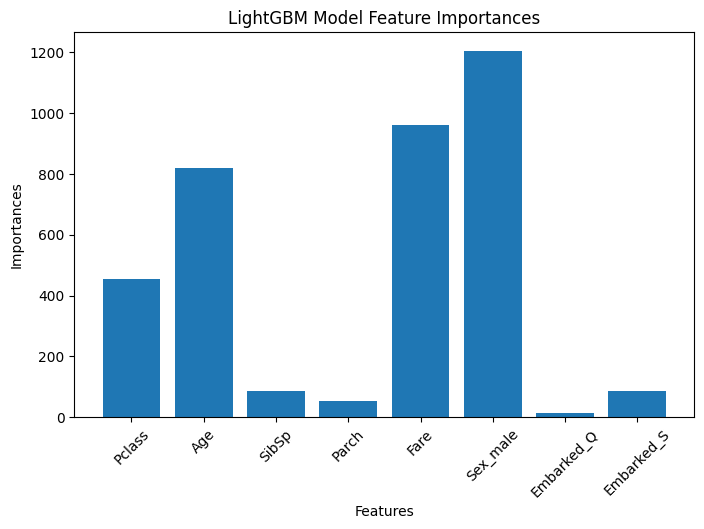

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(feature_names, importances)
plt.title("LightGBM Model Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importances")
plt.xticks(rotation=45)
plt.show()